In [ ]:
"""
NOTEBOOK 4 — Feature Fusion Model
══════════════════════════════════
Loads your already trained ResNet50 and MobileNetV2 backbones
from Drive, strips their classifier heads, concatenates their
feature vectors, and trains a new shared fusion classifier head.

Requires from Drive:
  - fine_tuned_resnet50_eca_checkpoint.pth    ← from Notebook 1
  - fine_tuned_mobilenetv2_eca_checkpoint.pth ← from Notebook 1
  - Dataset/train, val, test folders          ← from Notebook 1

Produces:
  - best_fusion_model.pth
  - final_fusion_checkpoint.pth
  - fusion_confusion_matrix.png
  - fusion_classification_report.txt
"""

# ─────────────────────────────────────────────
# 1. Mount & Imports
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drive_dir = "/content/drive/MyDrive"
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# 2. Transforms & Datasets
# ─────────────────────────────────────────────
input_size = 224

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(input_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),
                            scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

tta_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir = f"{drive_dir}/Dataset/train"
val_dir   = f"{drive_dir}/Dataset/val"
test_dir  = f"{drive_dir}/Dataset/test"

train_dataset    = datasets.ImageFolder(train_dir,
                                        transform=train_transforms)
val_dataset      = datasets.ImageFolder(val_dir,
                                        transform=val_test_transforms)
test_dataset     = datasets.ImageFolder(test_dir,
                                        transform=val_test_transforms)
test_dataset_tta = datasets.ImageFolder(test_dir,
                                        transform=tta_transforms)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes
print(f"Classes ({num_classes}): {class_names}")


Classes (8): ['Algal leaf spot', 'Brown blight', 'Gray blight', 'Green mirid bug', 'Healthy', 'Helopeltis', 'Red leaf spot', 'Red spider']


In [ ]:
# ─────────────────────────────────────────────
# 3. Class Weights + Loaders
# ─────────────────────────────────────────────
class_counts = {
    "Helopeltis":     917,
    "Algal leaf spot":910,
    "Red spider":     293,
    "Red leaf spot":  700,
    "Healthy":        1238,
    "Gray blight":    1127,
    "Brown blight":   823,
    "Green mirid bug":587
}

class_to_idx  = train_dataset.class_to_idx
total_samples = sum(class_counts.values())
weights       = [0.0] * num_classes
for name, idx in class_to_idx.items():
    weights[idx] = total_samples / (num_classes * class_counts[name])

class_weights_tensor = torch.tensor(weights,
                                    dtype=torch.float).to(device)

sample_weights = [weights[label]
                  for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(sample_weights,
                                len(sample_weights),
                                replacement=True)

train_loader    = DataLoader(train_dataset,    batch_size=32,
                             sampler=sampler,  num_workers=2,
                             pin_memory=True)
val_loader      = DataLoader(val_dataset,      batch_size=32,
                             shuffle=False,    num_workers=2,
                             pin_memory=True)
test_loader     = DataLoader(test_dataset,     batch_size=32,
                             shuffle=False,    num_workers=2,
                             pin_memory=True)
test_loader_tta = DataLoader(test_dataset_tta, batch_size=32,
                             shuffle=False,    num_workers=2,
                             pin_memory=True)


In [ ]:
# ─────────────────────────────────────────────
# 4. ECA LAYER
# ─────────────────────────────────────────────
class ECALayer(nn.Module):
    def __init__(self, channel, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k_size,
                                  padding=(k_size-1)//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2))
        y = self.sigmoid(y).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)


In [ ]:
# ─────────────────────────────────────────────
# 5. Feature Fusion Model
# Loads your saved backbone weights from Drive
# Strips classifier heads
# Adds new shared fusion classifier head
# ─────────────────────────────────────────────
class FeatureFusionModel(nn.Module):
    """
    Feature fusion model using your already trained backbones.

    What this does:
      1. Builds ResNet50 + MobileNetV2 with exact same
         architecture as Notebook 1
      2. Loads YOUR saved weights from Drive into both models
      3. Strips the classifier heads from both
      4. Keeps only the backbone feature extractors
      5. Concatenates their outputs: 2048 + 1280 = 3328
      6. Adds a new fusion classifier head on top

    Why use your saved weights instead of ImageNet:
      Your backbones are already adapted to tea diseases.
      ImageNet weights would need full retraining (3-4 hours).
      Your weights only need the fusion head trained (30-60 min).
    """

    def __init__(self, num_classes,
                 resnet_ckpt_path, mobilenet_ckpt_path):
        super().__init__()

        # ──────────────────────────────────────
        # ResNet50 backbone
        # Build exact same architecture as Notebook 1
        # then load your saved weights
        # ──────────────────────────────────────
        resnet = models.resnet50(weights=None)

        # Layer4WithECA wrapper — must match Notebook 1 exactly
        class Layer4WithECA(nn.Module):
            def __init__(self, layer4, eca):
                super().__init__()
                self.layer4 = layer4
                self.eca    = eca
            def forward(self, x):
                return self.eca(self.layer4(x))

        resnet.layer4 = Layer4WithECA(resnet.layer4, ECALayer(2048))

        # Classifier head must match Notebook 1 exactly
        # so that load_state_dict works without key errors
        resnet.fc = nn.Sequential(
          nn.Dropout(0.4),
          nn.Linear(resnet.fc.in_features, num_classes)
        )

        # Load YOUR trained weights
        state = torch.load(resnet_ckpt_path,
                           map_location=device,
                           weights_only=False)
        resnet.load_state_dict(state["model_state_dict"])
        print(f"ResNet50 loaded from Drive")
        print(f"  val_acc  = {state.get('val_accuracy', 'N/A')}")
        print(f"  test_acc = {state.get('test_accuracy', 'N/A')}")
        print(f"  oof_acc  = {state.get('oof_accuracy',  'N/A')}")

        # Strip classifier head — keep backbone only
        # resnet.avgpool outputs (B, 2048, 1, 1)
        # flatten gives (B, 2048)
        self.resnet_backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,   # includes ECA
            resnet.avgpool
        )

        # ──────────────────────────────────────
        # MobileNetV2 backbone
        # Build exact same architecture as Notebook 1
        # then load your saved weights
        # ──────────────────────────────────────
        mobilenet = models.mobilenet_v2(weights=None)

        # ECA placement — must match Notebook 1 exactly
        mobilenet.features.add_module(
            "eca", ECALayer(mobilenet.last_channel)
        )

        # Classifier head must match Notebook 1 exactly
        mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(mobilenet.last_channel, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Load YOUR trained weights
        state = torch.load(mobilenet_ckpt_path,
                           map_location=device,
                           weights_only=False)
        mobilenet.load_state_dict(state["model_state_dict"])
        print(f"\nMobileNetV2 loaded from Drive")
        print(f"  val_acc  = {state.get('val_accuracy', 'N/A')}")
        print(f"  test_acc = {state.get('test_accuracy', 'N/A')}")
        print(f"  oof_acc  = {state.get('oof_accuracy',  'N/A')}")

        # Strip classifier head — keep backbone only
        # mobilenet.features outputs (B, 1280, 7, 7)
        # after GAP gives (B, 1280)
        self.mobilenet_backbone = mobilenet.features
        self.mobilenet_gap      = nn.AdaptiveAvgPool2d(1)

        # ──────────────────────────────────────
        # Fusion classifier head
        # Input: 2048 (ResNet) + 1280 (MobileNet) = 3328
        # Same structure as the paper method
        # ──────────────────────────────────────
        self.fusion_head = nn.Sequential(
            nn.Linear(3328, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # ResNet50 feature extraction
        r_feat = self.resnet_backbone(x)      # (B, 2048, 1, 1)
        r_feat = r_feat.flatten(1)            # (B, 2048)

        # MobileNetV2 feature extraction
        m_feat = self.mobilenet_backbone(x)   # (B, 1280, 7, 7)
        m_feat = self.mobilenet_gap(m_feat)   # (B, 1280, 1, 1)
        m_feat = m_feat.flatten(1)            # (B, 1280)

        # Concatenate both feature vectors
        combined = torch.cat([r_feat, m_feat], dim=1)  # (B, 3328)

        # Classify
        return self.fusion_head(combined)


In [ ]:
# ─────────────────────────────────────────────
# 6. Freeze / Unfreeze Helpers
# ─────────────────────────────────────────────
def freeze_backbones(model):
    """
    Freeze both backbones completely.
    Only fusion_head parameters are trainable.
    Use for Phase 1 — teaches fusion head to use
    existing domain-adapted features.
    """
    for p in model.resnet_backbone.parameters():
        p.requires_grad = False
    for p in model.mobilenet_backbone.parameters():
        p.requires_grad = False
    # GAP has no parameters but set anyway
    for p in model.mobilenet_gap.parameters():
        p.requires_grad = False

    t = sum(p.numel() for p in model.parameters()
            if p.requires_grad)
    print(f"  [Frozen]  Trainable params: {t:,}")


def unfreeze_partial(model):
    """
    Unfreeze last layers of both backbones.
    ResNet50    : layer3 + layer4 (indices 6 and 7 in Sequential)
    MobileNetV2 : last 4 inverted residual blocks

    Use for Phase 2 — allows backbones to fine-tune
    slightly toward the fusion objective.
    """
    # ResNet50 — unfreeze layer3 (index 6) and layer4 (index 7)
    resnet_children = list(model.resnet_backbone.children())
    for block in resnet_children[6:]:   # layer3, layer4, avgpool
        for p in block.parameters():
            p.requires_grad = True

    # MobileNetV2 — unfreeze last 4 blocks
    mobilenet_children = list(model.mobilenet_backbone.children())
    for block in mobilenet_children[-4:]:
        for p in block.parameters():
            p.requires_grad = True

    t = sum(p.numel() for p in model.parameters()
            if p.requires_grad)
    print(f"  [Partial] Trainable params: {t:,}")


In [ ]:
# ─────────────────────────────────────────────
# 7. Training Function
# ─────────────────────────────────────────────
def train_phase(model, train_loader, val_loader,
                num_epochs, lr, save_path,
                phase_label, patience):

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-3
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    best_val_acc = 0.0
    best_wts     = copy.deepcopy(model.state_dict())
    patience_ctr = 0
    history      = {"train_loss":[], "val_loss":[],
                    "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):

        # Train
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += lbls.size(0)

        train_loss = run_loss / total
        train_acc  = 100 * correct / total

        # Validate
        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out     = model(imgs)
                v_loss += criterion(out, lbls).item() * imgs.size(0)
                v_corr += (out.argmax(1) == lbls).sum().item()
                v_tot  += lbls.size(0)

        val_loss = v_loss / v_tot
        val_acc  = 100 * v_corr / v_tot
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{phase_label}] Ep {epoch+1:02d}/{num_epochs} | "
              f"Train {train_acc:.2f}% | Val {val_acc:.2f}% | "
              f"LR {current_lr:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_wts     = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved ({val_acc:.2f}%)")
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_wts)
    return model, history, best_val_acc


In [ ]:
# ─────────────────────────────────────────────
# 8. Build Fusion Model
# ─────────────────────────────────────────────
resnet_ckpt_path    = f"{drive_dir}/fine_tuned_resnet50_eca_checkpoint.pth"
mobilenet_ckpt_path = f"{drive_dir}/fine_tuned_mobilenetv2_eca_checkpoint.pth"
fusion_save         = f"{drive_dir}/best_fusion_model.pth"

print("\n" + "="*55)
print("Building Feature Fusion Model")
print("="*55)

fusion_model = FeatureFusionModel(
    num_classes,
    resnet_ckpt_path,
    mobilenet_ckpt_path
).to(device)

total  = sum(p.numel() for p in fusion_model.parameters())
frozen = sum(p.numel() for p in fusion_model.parameters()
             if not p.requires_grad)
print(f"\nTotal params       : {total:,}")
print(f"Backbone params    : {frozen:,}  (will be frozen in Phase 1)")
print(f"Fusion head params : {total-frozen:,}")



Building Feature Fusion Model
ResNet50 loaded from Drive
  val_acc  = 95.75671852899576
  test_acc = 95.4834156669019
  oof_acc  = 95.3601213040182

MobileNetV2 loaded from Drive
  val_acc  = 91.15983026874116
  test_acc = 90.82568807339449
  oof_acc  = 89.2191053828658

Total params       : 29,671,758
Backbone params    : 0  (will be frozen in Phase 1)
Fusion head params : 29,671,758


In [ ]:
# ─────────────────────────────────────────────
# 9. Phase 1: Train Fusion Head Only
#
# Both backbones are frozen.
# Only the fusion head (3328→1024→512→8) is trained.
# Backbone weights are your tea-disease-adapted weights.
# The fusion head learns to combine features from both.
# Takes ~30-40 minutes on Colab GPU.
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 1 — Fusion head only (both backbones frozen)")
print("="*55)

freeze_backbones(fusion_model)

fusion_model, h1, _ = train_phase(
    fusion_model, train_loader, val_loader,
    num_epochs=10,
    lr=1e-3,
    save_path=fusion_save,
    phase_label="Fusion-P1",
    patience=4
)



PHASE 1 — Fusion head only (both backbones frozen)
  [Frozen]  Trainable params: 3,939,848
[Fusion-P1] Ep 01/10 | Train 91.77% | Val 94.48% | LR 1.00e-03
  ✓ Saved (94.48%)
[Fusion-P1] Ep 02/10 | Train 93.30% | Val 95.12% | LR 1.00e-03
  ✓ Saved (95.12%)
[Fusion-P1] Ep 03/10 | Train 94.07% | Val 94.84% | LR 1.00e-03
[Fusion-P1] Ep 04/10 | Train 94.69% | Val 94.77% | LR 1.00e-03
[Fusion-P1] Ep 05/10 | Train 94.63% | Val 94.27% | LR 1.00e-03
[Fusion-P1] Ep 06/10 | Train 94.31% | Val 94.77% | LR 1.00e-03
  Early stop at epoch 6


In [ ]:
# ─────────────────────────────────────────────
# 10. Phase 2: Partial Unfreeze
#
# Unfreeze last layers of both backbones.
# Lower LR to avoid disturbing well-trained weights.
# Allows backbones to adapt slightly toward the
# joint fusion objective.
# Takes ~60-90 minutes on Colab GPU.
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 2 — Partial unfreeze (fine-tune)")
print("="*55)

unfreeze_partial(fusion_model)

fusion_model, h2, best_val_acc = train_phase(
    fusion_model, train_loader, val_loader,
    num_epochs=10,
    lr=1e-4,
    save_path=fusion_save,
    phase_label="Fusion-P2",
    patience=6
)

# Load best weights
fusion_model.load_state_dict(
    torch.load(fusion_save, map_location=device,
               weights_only=False)
)
print(f"\nBest val_acc: {best_val_acc:.2f}%")


PHASE 2 — Partial unfreeze (fine-tune)
  [Partial] Trainable params: 27,209,038
[Fusion-P2] Ep 01/10 | Train 94.47% | Val 95.12% | LR 1.00e-04
  ✓ Saved (95.12%)
[Fusion-P2] Ep 02/10 | Train 94.56% | Val 94.77% | LR 1.00e-04
[Fusion-P2] Ep 03/10 | Train 94.34% | Val 95.47% | LR 1.00e-04
  ✓ Saved (95.47%)
[Fusion-P2] Ep 04/10 | Train 94.98% | Val 95.05% | LR 1.00e-04
[Fusion-P2] Ep 05/10 | Train 95.34% | Val 95.33% | LR 1.00e-04
[Fusion-P2] Ep 06/10 | Train 95.72% | Val 94.91% | LR 1.00e-04
[Fusion-P2] Ep 07/10 | Train 95.77% | Val 95.90% | LR 1.00e-04
  ✓ Saved (95.90%)
[Fusion-P2] Ep 08/10 | Train 95.33% | Val 95.47% | LR 1.00e-04
[Fusion-P2] Ep 09/10 | Train 95.89% | Val 95.62% | LR 1.00e-04
[Fusion-P2] Ep 10/10 | Train 95.91% | Val 95.40% | LR 1.00e-04

Best val_acc: 95.90%


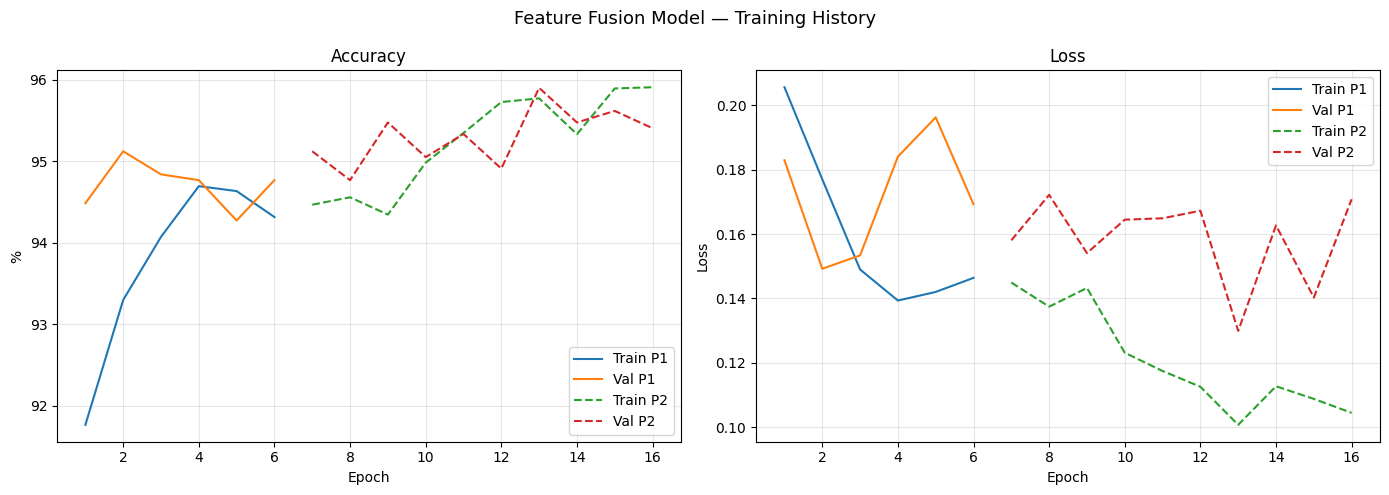

In [ ]:
# ─────────────────────────────────────────────
# 11. Plot Training History
# ─────────────────────────────────────────────
def plot_history(h1, h2, title="Fusion Model"):
    e1 = range(1, len(h1["train_acc"]) + 1)
    e2 = range(len(e1) + 1,
               len(e1) + len(h2["train_acc"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(e1, h1["train_acc"], label="Train P1")
    axes[0].plot(e1, h1["val_acc"],   label="Val P1")
    axes[0].plot(e2, h2["train_acc"], "--", label="Train P2")
    axes[0].plot(e2, h2["val_acc"],   "--", label="Val P2")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("%")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(e1, h1["train_loss"], label="Train P1")
    axes[1].plot(e1, h1["val_loss"],   label="Val P1")
    axes[1].plot(e2, h2["train_loss"], "--", label="Train P2")
    axes[1].plot(e2, h2["val_loss"],   "--", label="Val P2")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{drive_dir}/fusion_training_history.png",
                dpi=150)
    plt.show()

plot_history(h1, h2, title="Feature Fusion Model — Training History")

In [ ]:
# ─────────────────────────────────────────────
# 12. Evaluate with TTA
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("TEST EVALUATION — Feature Fusion Model")
print("="*55)

fusion_model.eval()
base_probs, tta_probs, all_labels = [], [], []

with torch.no_grad():
    for (imgs, lbls), (imgs_t, _) in zip(test_loader,
                                          test_loader_tta):
        base_probs.append(
            F.softmax(fusion_model(imgs.to(device)),
                      dim=1).cpu()
        )
        tta_probs.append(
            F.softmax(fusion_model(imgs_t.to(device)),
                      dim=1).cpu()
        )
        all_labels.extend(lbls.numpy())

probs  = (torch.cat(base_probs) + torch.cat(tta_probs)) / 2.0
preds  = probs.argmax(1).numpy()
labels = np.array(all_labels)
acc    = (preds == labels).mean() * 100

precision = precision_score(labels, preds, average='weighted')
recall    = recall_score(labels,    preds, average='weighted')
f1        = f1_score(labels,        preds, average='weighted')

print(f"\nFusion Model Test Accuracy (TTA) : {acc:.2f}%")
print(f"Precision                        : {precision:.4f}")
print(f"Recall                           : {recall:.4f}")
print(f"F1 Score                         : {f1:.4f}")

report = classification_report(labels, preds,
                               target_names=class_names)
print("\nClassification Report:\n", report)

# Save report
with open(f"{drive_dir}/fusion_classification_report.txt", "w") as f:
    f.write(f"Feature Fusion Model\n\n")
    f.write(report)
print("Classification report saved to Drive.")


TEST EVALUATION — Feature Fusion Model

Fusion Model Test Accuracy (TTA) : 96.82%
Precision                        : 0.9692
Recall                           : 0.9682
F1 Score                         : 0.9684

Classification Report:
                  precision    recall  f1-score   support

Algal leaf spot       0.98      0.98      0.98       196
   Brown blight       0.94      0.93      0.94       177
    Gray blight       0.96      0.95      0.95       242
Green mirid bug       0.88      0.98      0.93       126
        Healthy       0.99      1.00      1.00       266
     Helopeltis       0.99      0.95      0.97       197
  Red leaf spot       1.00      1.00      1.00       150
     Red spider       0.98      0.92      0.95        63

       accuracy                           0.97      1417
      macro avg       0.97      0.96      0.96      1417
   weighted avg       0.97      0.97      0.97      1417

Classification report saved to Drive.


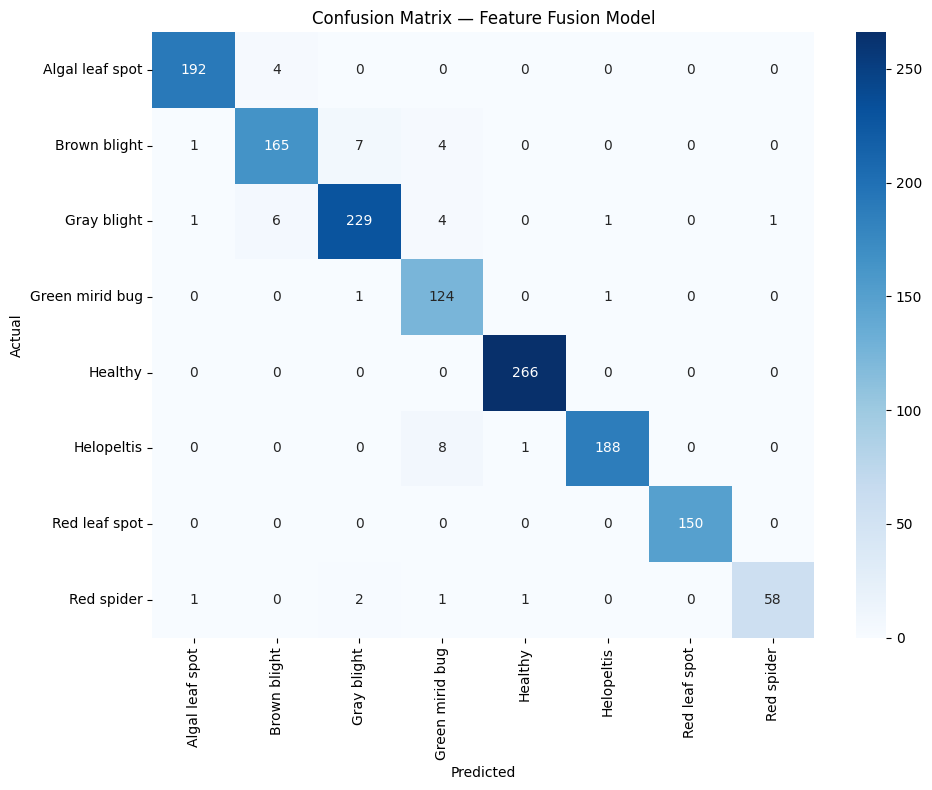

In [ ]:
# ─────────────────────────────────────────────
# SECTION 13 — Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Feature Fusion Model")
plt.tight_layout()
plt.savefig(f"{drive_dir}/fusion_confusion_matrix.png", dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# SECTION 14 — Save Final Checkpoint
# ─────────────────────────────────────────────
torch.save({
    "model_state_dict": fusion_model.state_dict(),
    "model_name":       "feature_fusion",
    "num_classes":      num_classes,
    "class_to_idx":     train_dataset.class_to_idx,
    "idx_to_class":     {v: k for k, v in
                         train_dataset.class_to_idx.items()},
    "val_accuracy":     float(best_val_acc),
    "test_accuracy":    float(acc),
    "resnet_backbone":  resnet_ckpt_path,
    "mobilenet_backbone": mobilenet_ckpt_path,
}, f"{drive_dir}/final_fusion_checkpoint.pth")

print(f"\n✓ Final fusion checkpoint saved.")
print(f"  Val  Accuracy : {best_val_acc:.2f}%")
print(f"  Test Accuracy : {acc:.2f}%")


✓ Final fusion checkpoint saved.
  Val  Accuracy : 95.90%
  Test Accuracy : 96.82%


In [ ]:
# ─────────────────────────────────────────────
# SECTION 15 — Per-Class Accuracy All Models
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("PER-CLASS ACCURACY — ALL MODELS")
print("="*65)

# Load test probs saved by Notebook 2
test_resnet_probs    = np.load(f"{drive_dir}/test_resnet_probs.npy")
test_mobilenet_probs = np.load(f"{drive_dir}/test_mobilenet_probs.npy")
test_labels_nb2      = np.load(f"{drive_dir}/test_labels.npy")

# Load stacking predictions saved by Notebook 3
lr_preds  = np.load(f"{drive_dir}/lr_test_preds.npy")
nn_preds  = np.load(f"{drive_dir}/nn_test_preds.npy")

# Recompute weights from OOF accuracy
resnet_state    = torch.load(resnet_ckpt_path,
                             map_location=device,
                             weights_only=False)
mobilenet_state = torch.load(mobilenet_ckpt_path,
                             map_location=device,
                             weights_only=False)

r_oof = float(resnet_state.get("oof_accuracy",   95.97))
m_oof = float(mobilenet_state.get("oof_accuracy", 94.84))
total = r_oof + m_oof
w1    = r_oof / total
w2    = m_oof / total

test_r = torch.tensor(test_resnet_probs)
test_m = torch.tensor(test_mobilenet_probs)

# All model predictions
resnet_preds  = test_r.argmax(1).numpy()
mobile_preds  = test_m.argmax(1).numpy()
wavg_preds    = (w1 * test_r + w2 * test_m).argmax(1).numpy()
fusion_preds  = preds   # already computed in Section 12

# Header
print(f"\n{'─'*90}")
print(f"{'Class':<22} {'ResNet':>8} {'Mobile':>8} "
      f"{'W-Avg':>8} {'Stk-LR':>8} {'Stk-NN':>8} "
      f"{'Fusion':>8} {'Best':>12}")
print(f"{'─'*90}")

for i, cls in enumerate(class_names):
    mask   = test_labels_nb2 == i
    acc_r  = (resnet_preds[mask]  == test_labels_nb2[mask]).mean()
    acc_m  = (mobile_preds[mask]  == test_labels_nb2[mask]).mean()
    acc_e  = (wavg_preds[mask]    == test_labels_nb2[mask]).mean()
    acc_lr = (lr_preds[mask]      == test_labels_nb2[mask]).mean()
    acc_nn = (nn_preds[mask]      == test_labels_nb2[mask]).mean()
    acc_f  = (fusion_preds[mask]  == test_labels_nb2[mask]).mean()

    best_cls = max(
        [("ResNet",   acc_r),
         ("Mobile",   acc_m),
         ("W-Avg",    acc_e),
         ("Stk-LR",   acc_lr),
         ("Stk-NN",   acc_nn),
         ("Fusion",   acc_f)],
        key=lambda x: x[1]
    )[0]

    print(f"{cls:<22} {acc_r:>8.3f} {acc_m:>8.3f} "
          f"{acc_e:>8.3f} {acc_lr:>8.3f} {acc_nn:>8.3f} "
          f"{acc_f:>8.3f} {best_cls:>12}")

print(f"{'─'*90}")

# Overall row
ov_r  = accuracy_score(test_labels_nb2, resnet_preds)
ov_m  = accuracy_score(test_labels_nb2, mobile_preds)
ov_e  = accuracy_score(test_labels_nb2, wavg_preds)
ov_lr = accuracy_score(test_labels_nb2, lr_preds)
ov_nn = accuracy_score(test_labels_nb2, nn_preds)
ov_f  = acc / 100

print(f"{'OVERALL':<22} {ov_r:>8.3f} {ov_m:>8.3f} "
      f"{ov_e:>8.3f} {ov_lr:>8.3f} {ov_nn:>8.3f} "
      f"{ov_f:>8.3f}")
print(f"{'─'*90}")

# Save to Drive
with open(f"{drive_dir}/perclass_all_models.txt", "w") as f:
    f.write(f"{'Class':<22} {'ResNet':>8} {'Mobile':>8} "
            f"{'W-Avg':>8} {'Stk-LR':>8} {'Stk-NN':>8} "
            f"{'Fusion':>8} {'Best':>12}\n")
    f.write("─"*90 + "\n")
    for i, cls in enumerate(class_names):
        mask   = test_labels_nb2 == i
        acc_r  = (resnet_preds[mask] == test_labels_nb2[mask]).mean()
        acc_m  = (mobile_preds[mask] == test_labels_nb2[mask]).mean()
        acc_e  = (wavg_preds[mask]   == test_labels_nb2[mask]).mean()
        acc_lr = (lr_preds[mask]     == test_labels_nb2[mask]).mean()
        acc_nn = (nn_preds[mask]     == test_labels_nb2[mask]).mean()
        acc_f  = (fusion_preds[mask] == test_labels_nb2[mask]).mean()
        best_cls = max(
            [("ResNet", acc_r), ("Mobile", acc_m),
             ("W-Avg",  acc_e), ("Stk-LR", acc_lr),
             ("Stk-NN", acc_nn),("Fusion", acc_f)],
            key=lambda x: x[1])[0]
        f.write(f"{cls:<22} {acc_r:>8.3f} {acc_m:>8.3f} "
                f"{acc_e:>8.3f} {acc_lr:>8.3f} {acc_nn:>8.3f} "
                f"{acc_f:>8.3f} {best_cls:>12}\n")
    f.write("─"*90 + "\n")
    f.write(f"{'OVERALL':<22} {ov_r:>8.3f} {ov_m:>8.3f} "
            f"{ov_e:>8.3f} {ov_lr:>8.3f} {ov_nn:>8.3f} "
            f"{ov_f:>8.3f}\n")

print("\nPer-class table saved: perclass_all_models.txt")


PER-CLASS ACCURACY — ALL MODELS

──────────────────────────────────────────────────────────────────────────────────────────
Class                    ResNet   Mobile    W-Avg   Stk-LR   Stk-NN   Fusion         Best
──────────────────────────────────────────────────────────────────────────────────────────
Algal leaf spot           0.954    0.944    0.964    0.954    0.959    0.980       Fusion
Brown blight              0.910    0.910    0.921    0.921    0.927    0.932       Fusion
Gray blight               0.934    0.777    0.921    0.930    0.926    0.946       Fusion
Green mirid bug           0.937    0.913    0.960    0.960    0.960    0.984       Fusion
Healthy                   1.000    0.977    1.000    0.996    0.996    1.000       ResNet
Helopeltis                0.954    0.883    0.959    0.959    0.959    0.954        W-Avg
Red leaf spot             0.987    0.953    0.973    0.987    0.987    1.000       Fusion
Red spider                0.937    0.968    0.984    0.984    0.